# Examen final B1 2025-2026: Partie Colab

**Début** : Notebook disponible à 15h30

**Fin** : A rendre via BlackBoard avant 16h30.
&nbsp;

------

**Avant de commencer** :
- <font color='red'> Enregistrez une copie de ce fichier dans votre drive</font>
- <font color='red'> Modifier le nom du document en y incluant votre **nom + prénom**</font>

------



In [ ]:
# A exécuter
import pandas as pd
import seaborn as sns
import numpy as np
np.set_printoptions(legacy='1.25')

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression as OLS
from sklearn.linear_model import LogisticRegression as LReg
from sklearn.neighbors import KNeighborsClassifier as KNNC
from sklearn.neighbors import KNeighborsRegressor as KNNR
from sklearn.model_selection import train_test_split, KFold, validation_curve
from sklearn.preprocessing import StandardScaler
cv5sh = KFold(n_splits=5, shuffle=True)
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import accuracy_score

On charge le jeu de données dans la cellule suivante, chaque observation correspond à un vin blanc et des informations sur ses propriétés :

In [ ]:
# A exécuter
df = pd.read_csv('https://www.dropbox.com/scl/fi/12eizqgcy2cvr2kesywe3/final_exam_data.csv?rlkey=5wl2mdzv43cthw7a5csilzu7n&st=6py54njc&dl=1')
df

,volatile acidity,citric acid,total sulfur dioxide,density,pH,sulphates,quality,sweet,alcohol
0,0.27,0.36,170.0,1.00100,3.00,0.45,6,1,8.8
1,0.30,0.34,132.0,0.99400,3.30,0.49,6,0,9.5
2,0.28,0.40,97.0,0.99510,3.26,0.44,6,0,10.1
3,0.23,0.32,186.0,0.99560,3.19,0.40,6,0,9.9
4,0.23,0.32,186.0,0.99560,3.19,0.40,6,0,9.9
...,...,...,...,...,...,...,...,...,...
4893,0.21,0.29,92.0,0.99114,3.27,0.50,6,0,11.2
4894,0.32,0.36,168.0,0.99490,3.15,0.46,5,0,9.6
4895,0.24,0.19,111.0,0.99254,2.99,0.46,6,0,9.4
4896,0.29,0.30,110.0,0.98869,3.34,0.38,7,0,12.8


**Description des variables:**

**Volatile acidity** : Mesure la quantité d’acides volatils présents dans le vin.

**Citric acid** : Indique la concentration d’acide citrique.

**Total sulfur dioxide** : Représente la quantité totale de dioxyde de soufre (un conservateur).

**Density** : Correspond à la densité du vin.

**pH** : Indique le niveau d’acidité globale du vin.

**Sulphates** : Mesure la concentration de sulfates.

**Quality** : Note globale attribuée au vin (entre 1 et 10).

**Sweet** : Variable indiquant si le vin est doux (`sweet=1`) ou non (`sweet=0`), en fonction de sa teneur en sucre.

**Alcohol** : Indique le pourcentage d’alcool dans le vin.

# Partie A (6 points).

#### **Question A.1**

---

Les vins doux (`sweet = 1`) sont-ils de meilleurs qualité que les autres vins ?

**(3 points)**

---

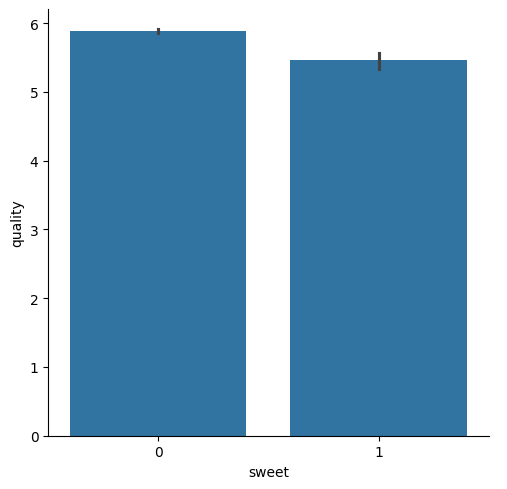

In [ ]:
sns.catplot(data=df,x='sweet', y='quality',kind='bar')

In [ ]:
df_sw=df[df['sweet']==1]
df_sw['quality'].describe()

,quality
count,85.000000
mean,5.458824
std,0.568057
min,5.000000
25%,5.000000
50%,5.000000
75%,6.000000
max,7.000000


In [ ]:
df_nsw=df[df['sweet']==0]
df_nsw['quality'].describe()

,quality
count,4813.000000
mean,5.885311
std,0.888493
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,9.000000


En moyenne, les vins doux sont notés vers 5.45, alors que les vins non doux sont noté plus vers 5.88, donc les vins doux sont légèrement moins bien notés mais la différence est faible.

In [ ]:
pd.crosstab(df['sweet'],df['quality'],normalize='index')

quality,3,4,5,6,7,8,9
sweet,,,,,,,
0,0.004155,0.033867,0.292541,0.449823,0.182215,0.03636,0.001039
1,0.000000,0.000000,0.576471,0.388235,0.035294,0.00000,0.000000


les vins doux sont tous notés 5, 6 ou 7, alors que les vins non doux ont une meilleure répartition des notes, en gros c'est pas forcément comparable.
On voit aussi qu'il y a que 85 vins doux contre 4813 vins non doux

#### **Question A.2**

---

La densité est-elle influencée par le taux d'alcool ?


**(3 points)**

---

<Axes: xlabel='alcohol', ylabel='density'>

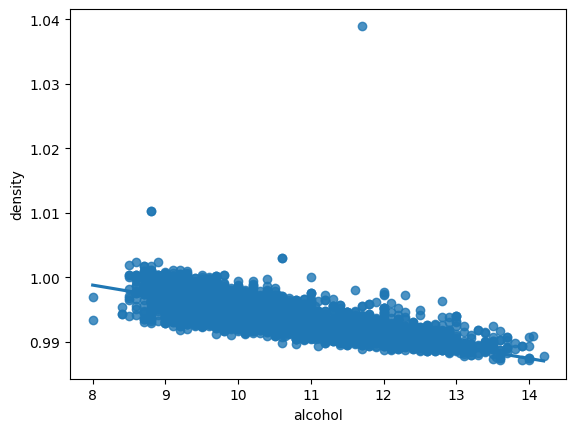

In [ ]:
sns.regplot(data=df, x='alcohol', y='density')

<Axes: xlabel='alcohol', ylabel='density'>

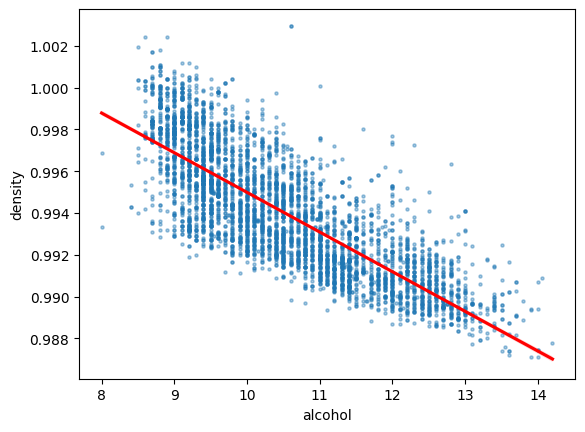

In [ ]:
df_1=df[df['density'] < 1.01]
sns.regplot(data=df_1, x='alcohol', y='density', line_kws={'color':'red'},scatter_kws={'s':5,'alpha':0.4})

Oui , on observe clairement une corrélation entre le taux d'alcool et la densité du vin, une fois enlevée les valeurs abérantes.

# Partie B (20 points).

#### **Question B.1**

---

Que fait la cellule de code suivante ? Commentez la sortie.

<font color='red'>NOTE: n'essayez pas de double-cliquer, d'exécuter ou d'éditer la cellule suivante : c'est une copie d'écran (image) d'un bout de code et de la sortie qu'il produit. </font>


**(4 points)**

---

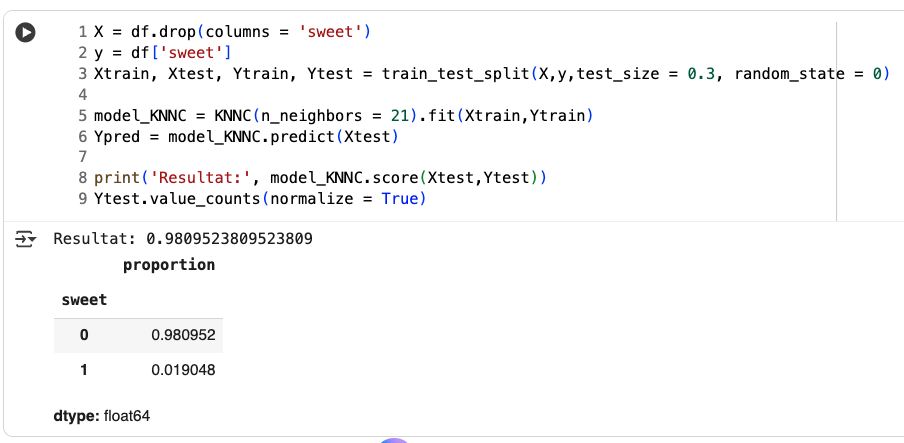

On realise une classification pour predire si le vin est doux ou non. On utilise toutes les variables. On fait une partition (70 % en entrainement) avec un random state à 0 pour assurer la reproductabilité de l'expérience, et on utilise la méthode des KNN avec un nombre de voisin K à 21.

l'accuracy est de 98% du modèle, ce qui semble très bien

mais en réalité la proportion de vin non doux est de 98% aussi donc le modèle n'est pas mieux qu'un modèle qui prédirait toujours 0.

#### **Question B.2**

---

Que fait la cellule de code suivante ? Commentez la sortie. Comparez avec les performances obtenues dans la cellule de code de la question précédente.

<font color='red'>NOTE: n'essayez pas de double-cliquer, d'exécuter ou d'éditer la cellule suivante : c'est une copie d'écran (image) d'un bout de code et de la sortie qu'il produit. </font>


**(4 points)**

---

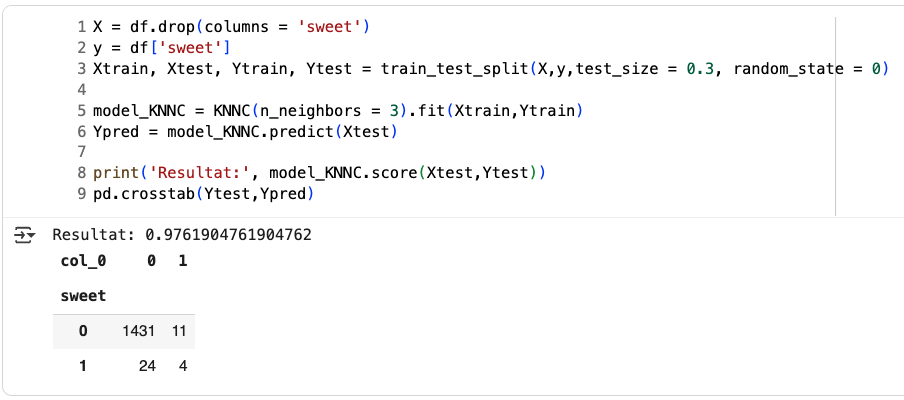

on utilise le même modèle que précédemment avec cette fois un nombre de voisin K = 3, et on tente toujours de prédire si le vin est doux ou non.

L'accuracy est cette fois de 97%, un peu moins bonne.

on a également la répartition des prédiction comparées aux valeurs de test, il y a 1431 vrai négatifs, et 4 vrais positifs, mais surtout ce qu'il faut remarquer c'est que sur les 28 vins doux, seuls 4 ont été bien prédits, les 24 autres sont prédits non doux. Donc le modèle est mauvais.

#### **Question B.3**

---

Que fait la cellule de code suivante ? Commentez la sortie.

<font color='red'>NOTE: n'essayez pas de double-cliquer, d'exécuter ou d'éditer la cellule suivante : c'est une copie d'écran (image) d'un bout de code et de la sortie qu'il produit.  </font>


**(4 points)**

---

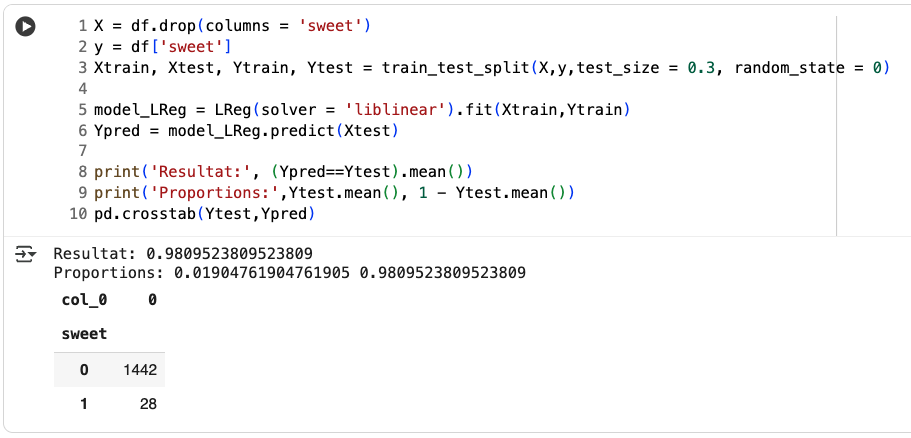

on crée un modèle pour qu'il prédise encore si un vin est doux ou non, qu'on sépare de la même manière

on utilise cette fois un modèle de regression linéaire.

L'accuracy est de 98%, comme avec KNN et qui corresponds à la proportion de 0 dans l'ensemble de test (98% aussi, mais exact à la virgule près) donc pas très bonne.

Et on se rend compte que le modèle prédit en réalité toujours 0, il ne prédit jamais qu'un vin est doux. *texte en italique*

#### **Question B.4**

---

Que fait la cellule de code suivante ? Commentez la sortie.

<font color='red'>NOTE: n'essayez pas de double-cliquer, d'exécuter ou d'éditer la cellule suivante : c'est une copie d'écran (image) d'un bout de code et de la sortie qu'il produit. </font>


**(4 points)**

---

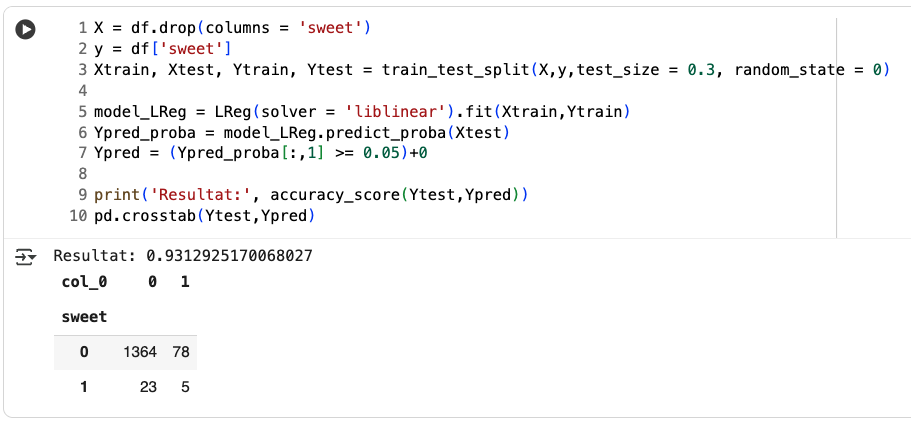

on crée un modèle pour qu'il prédise encore si un vin est doux ou non, qu'on sépare de la même manière.

Toujours un modèle de régression linéaire, mais cette fois on change le seuil, si la probabilité que le vin soit doux est supérieure à 0.05 (et non 0.5 normalement), le vin est prédit comme doux. On voit que l'accuracy tombe à 93%, donc moins bonne.

Mais sur les 28 vins doux, 5 sont prédits correctements, ce qui est très légèrement mieux que le premier modèle KNN (4 étaient prédits), mais c'est toujours loin d'etre efficace.

#### **Question B.5**

---

La cellule suivante n'a pas été executée. Pouvez-vous prédire sa sortie ?

Information nécessaire : le nombre de vin doux dans le jeu de données d'entrainement est de 57.

<font color='red'>NOTE: n'essayez pas de double-cliquer, d'exécuter ou d'éditer la cellule suivante : c'est une copie d'écran (image) d'un bout de code et de la sortie qu'il produit. </font>


**(4 points)**

---

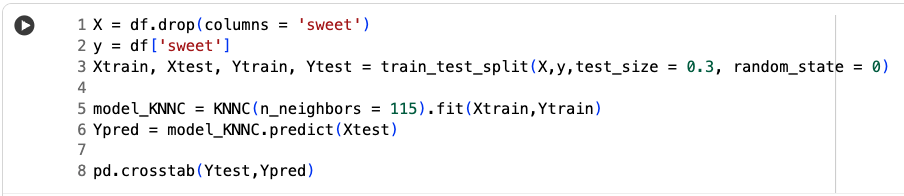

on fait un modèle de KNN avec la même séparation en train set et test set, avec cette fois un nombre de voisin k = 115, pour prédire si le vin est doux ou non.

le crosstab doit renvoyer la matrice de confusion avec le nombre de prédiction 0 et 1 comparé aux données du test set.

le modèle se basera sur les 115 points les plus similaires, or comme il y a 57 vins doux dans les données d'entrainement, sur les 115 voisins il y aura toujours minimum 58 vins non doux et ce sera vin non doux qui sera prédits

on peut donc être sur que le cross tab renverra comme à la question b.3, une seule colonne car aucune prédiction 1.

# Partie C (14 points).

#### **Question C.1**

---

Que fait la cellule de code suivante ? Commentez la sortie.

<font color='red'>NOTE: n'essayez pas de double-cliquer, d'exécuter ou d'éditer la cellule suivante : c'est une copie d'écran (image) d'un bout de code et de la sortie qu'il produit. </font>


**(4 points)**

---

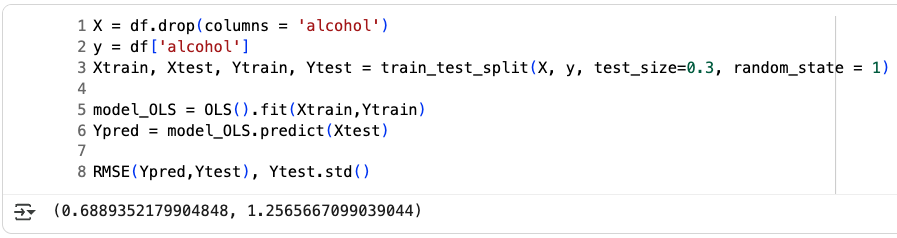

on passe à un modèle de regression, pour déterminer le % d'alcool dans le vin. On avait vu dans la première partie que c'était en partie corrélé à la densité mais on utilise toutes les données pour tenter de prédire le % d'alcool ici.
On fait une répartition à 70% en données d'entrainements.

On utilise un modèle OLS qu'on entraine puis on calcule la RLMSE

La RMSE est de 0.69, on la compare à l'écart type du jeu de donnée de test, qui est de 1.26.

On voit que la RMSE est meilleure que l'écart type, ca veut dire qu'en moyenne le modèle se trompe de 0.69% sur le degré d'alcool, alors que l'écart type est de 1.26%.

#### **Question C.2**

---

Commentez la sortie graphique suivante. La droite `y=x` est reproduite en rouge.

<font color='red'>NOTE: n'essayez pas de double-cliquer ou d'éditer la cellule suivante : c'est une copie d'écran (image) d'une sortie graphique. </font>


**(2 points)**

---

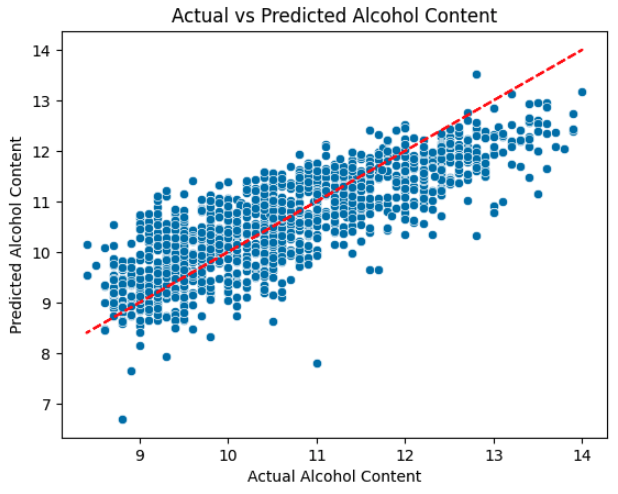

On voit que globalement les points sont assez bien corrélés à la ligne y=x, si ils étaient parfaitement ressérés autour de cette droite le modèle aurait une super prédiction.

Pour des % d'alcool faible, le modèle a tendance à prédire plus élevé et pour des % d'alcool élevé, le modèle a tendance à prédire plus faible.

L'écart type de prédiction est en fait beaucoup plus resseré que l'écart type véritable de la réparition des % d'alcool.

#### **Question C.3**

---

Que fait la cellule de code suivante ? Commentez la sortie.

<font color='red'>NOTE: n'essayez pas de double-cliquer, d'exécuter ou d'éditer la cellule suivante : c'est une copie d'écran (image) d'un bout de code et de la sortie qu'il produit. </font>


**(4 points)**

---

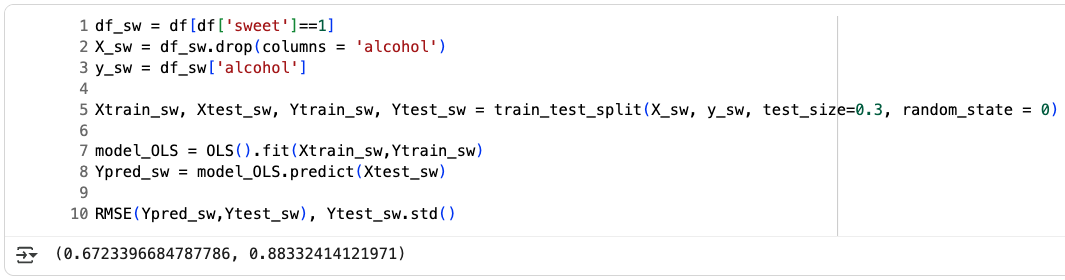

on crée un sous ensemble du jeu de donnée appelé df_sw qui contient que les données des vins doux

puis on va tenter de déterminer le % d'alcool parmis ces vins doux en utilisant un modèle OLS de la même manière que ci dessus, avec une répatition 70% dans l'ensemble d'entrainement etc...

La RMSE est de 0.67, et l'écart-type de 0.88, la RMSE est donc meilleure que l'écart-type mais le ratio est moins bon que dans l'ensemble global et pas seulement les vins doux.

#### **Question C.4**

---

Que fait la cellule de code suivante ? Commentez la sortie.

<font color='red'>NOTE: n'essayez pas de double-cliquer, d'exécuter ou d'éditer la cellule suivante : c'est une copie d'écran (image) d'un bout de code et de la sortie qu'il produit. </font>


**(4 points)**

---

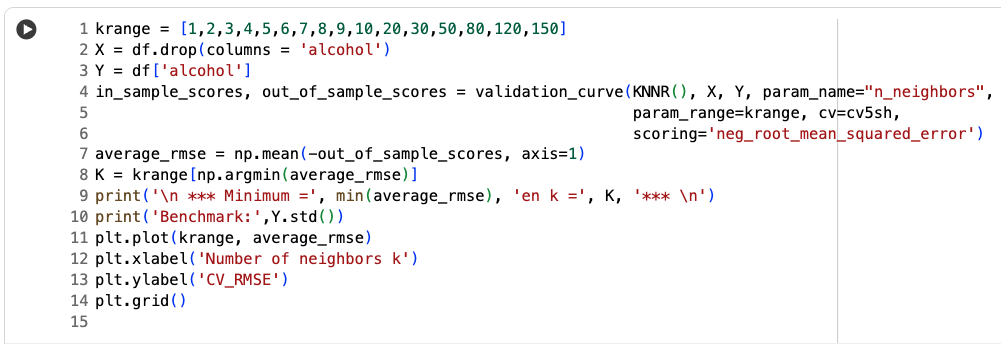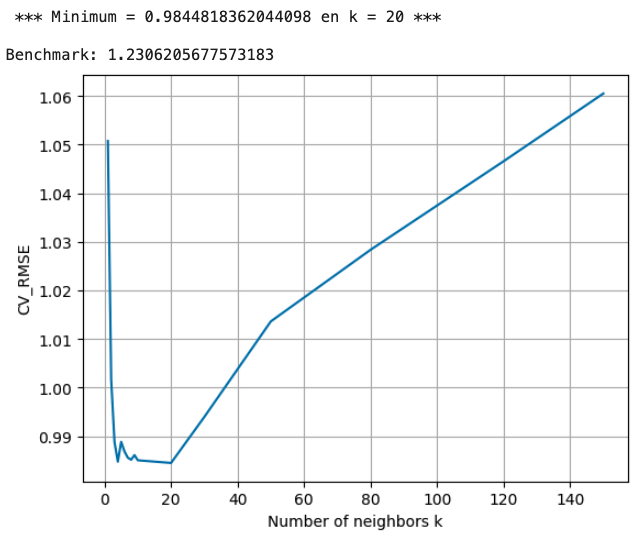

On est dans le même cadre que la question C1 (classification, target, features; mais la méthode va changer, de même que l'évaluation)

Méthode = K plus proches voisins (KNN)

On calcule la performance en validation croisee pour plusieurs valeurs du nombre de voisins K,
cf. variable 'krange'

on fait cela pour obtenir la RMSE, qu'on va chercher à minimiser.

On obtient une courbe de forme en U : un nombre de voisins faible a de mauvaises performances (overfitting, trop de variabilité), un nombre de voisins trop grand de même (underfitting, pas assez de variabilité dans les prévisions possibles)
On peut lire la valeur optimale de la prévision au-dessus de la figure, elle est obtenue pour K=20 voisins, et une RMSE égale à 0.98.

On compare cela à l'écart type qui est de 1.23, la RMSE est meilleure que cela.

Donc le modèle OLS de la question 1 qui donnait une RPMSE à 0.69 était meilleur, étant donné un écart-type à 1.25 (la différence s'explique par l'aléa des données d'entrainement ou de test, alors que là on applique une validation croisée). Il faudrait pour être sur, tester à nouveau ce modèle OLS avec une validation croisée.

Egalement, il faudrait normaliser les données pour KNN car le calcul de distance est biaisé par les échelles... ce qui n'est pas nécessaire (même unutile) pour OLS.